# Part 13 — nnPU follow-up, Zadanie 5: factor decomposition

Isolates which specific design choice — `pos_weight`, the BCE/nnPU zero-interpretation, or
the regularizers/contrastive term — drives any observed difference, via paired comparisons
(all paired by repetition `r`, per rule 4) and a class-prevalence breakdown:

| pair | isolates |
|---|---|
| `0004` vs. `0007` | `pos_weight` alone (both have `+contractive+InfoNCE`, both `bce`) |
| `0007` vs. `0006` | zero-interpretation alone, *with* regularizers |
| `0011` vs. `0012` | zero-interpretation alone, *without* regularizers |
| `0000` vs. `0011` | `pos_weight` alone, *without* regularizers |
| `0004`/`0005`/`0006`/`0008` | 2x2: {`bce`,`nnpu`} x {no Jaccard, Jaccard}, with interaction |

Plus: per-class-prevalence-quintile breakdown (does `nnpu` flatten the quality-vs-prevalence
relationship `max_positive_weight=20` is known to distort for `bce`?), predicted-positive
fraction at threshold 0.5 vs. true prevalence per variant, and reliability (calibration)
curves.

Every paired delta is checked against `part_9`'s `seed_null_distribution.csv` before being
read as real (rule 4) — re-read directly from disk rather than recomputed, so a change to the
null table there is picked up here automatically on re-run.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.calibration import calibration_curve
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head, per_class_metrics, probabilities_from_logits
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-28 15:32:06,812 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:32:06,815 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 15:32:06,909 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 15:32:06,911 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 15:32:06,912 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 15:32:06,913 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:32:06,928 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 15:32:06,940 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 15:32:06,941 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0000": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0000"),
    "0004": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0004"),
    "0005": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0005"),
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006"),
    "0007": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0000"),
    "0008": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0001"),
    "0011": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0002"),
    "0012": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0003"),
}
PAIRS = [
    ("pos_weight alone", "0007", "0004"),
    ("zero-interpretation, with regularizers", "0007", "0006"),
    ("zero-interpretation, without regularizers", "0011", "0012"),
    ("pos_weight alone, without regularizers", "0000", "0011"),
]
FACTORIAL_2X2 = {"bce_no_jaccard": "0004", "nnpu_no_jaccard": "0006", "bce_jaccard": "0005", "nnpu_jaccard": "0008"}

REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256
QUINTILE_COUNT = 5

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
SEED_NULL_FRAME = pd.read_csv(RESULTS_DIRECTORY / "seed_null_distribution.csv", dtype={"variant": str, "repetition": str})

theme = resolve_theme(None)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())

## Per-class AP/AUROC, predicted probabilities, and train-set positive counts, across 8 variants x 5 repetitions

### Methodology
#### Theoretical
- All downstream analyses in this notebook (paired comparisons, the 2x2 factorial, the prevalence-quintile breakdown, calibration) require the same three raw ingredients per (variant, repetition): per-class discrimination metrics on `test`, the raw predicted probabilities (for calibration), and each class's positive count in `train` (to bin classes by prevalence). These are computed once here and reused throughout the notebook.
- 8 variants are loaded (`VARIANT_SPECS`): `0000`/`0004`/`0005`/`0006` (architecture-predictive campaign) and `0007`/`0008`/`0011`/`0012` (nnpu-objective-controls campaign) — chosen specifically to instantiate the paired comparisons and the 2x2 factorial listed in the title cell.

#### Implementation
- `collect_targets_and_masks(dataset)`: as in earlier notebooks, batches a dataset through a `DataLoader` (`BATCH_SIZE=256`) and concatenates the `molecule` target/mask tensors.
- Train positive counts (`train_positive_count`, one integer per class) are computed once, from the first campaign loaded's `train` partition: `(train_targets * train_mask).sum(dim=0)`.
- Test targets/masks (`test_targets_masks_by_campaign`) are computed once per campaign, not per variant — `0000`/`0004`/`0005`/`0006` share the architecture-predictive campaign's fixed test split, `0007`/`0008`/`0011`/`0012` share the nnpu-objective-controls campaign's.
- Per (variant, repetition): model logits for `head_molecule_primary` are collected over `test`; `probabilities_from_logits(logits, "multi_label")` converts logits to probabilities (stored in `probabilities_by_variant_repetition`); `per_class_metrics(probabilities, test_targets_np, THRESHOLD=0.5, test_mask_np)` returns a per-class-indexed frame including `average_precision`/`roc_auc`, stored in `per_class_frames`.

### Notes
- The cell prints one `"{variant}: done"` line per variant (8 total), with no numeric summary — the actual metrics only become visible via `per_class_frames`/`macro_frame` in the next cell.
- No aggregation happens here; this cell only builds the four dictionaries (`per_class_frames`, `probabilities_by_variant_repetition`, `test_targets_masks_by_campaign`, `train_positive_count`) consumed by every later cell in the notebook.


In [4]:
def collect_targets_and_masks(dataset) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD])
        mask_batches.append(masks[TARGET_FIELD])
    return torch.cat(target_batches, dim=0).float(), torch.cat(mask_batches, dim=0).bool()


wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
per_class_frames: dict[tuple[str, int], pd.DataFrame] = {}
probabilities_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}
test_targets_masks_by_campaign: dict[str, tuple[np.ndarray, np.ndarray]] = {}
train_positive_count: np.ndarray | None = None

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        partitions = wrapper.active_dataset.create_partitions()

        if train_positive_count is None:
            train_targets, train_mask = collect_targets_and_masks(partitions.train)
            train_positive_count = (train_targets * train_mask).sum(dim=0).numpy()

        if campaign_id not in test_targets_masks_by_campaign:
            test_targets, test_mask = collect_targets_and_masks(partitions.test)
            test_targets_masks_by_campaign[campaign_id] = (test_targets.numpy(), test_mask.numpy())
        test_targets_np, test_mask_np = test_targets_masks_by_campaign[campaign_id]

        logits_chunks = []
        loader = DataLoader(partitions.test, batch_size=BATCH_SIZE, shuffle=False)
        with torch.no_grad():
            for _, spectra, _, _ in loader:
                logits_chunks.append(model(spectra.float().to(device))[f"head_{HEAD_NAME}"].cpu().numpy())
        logits = np.concatenate(logits_chunks, axis=0)
        probabilities = probabilities_from_logits(logits, "multi_label")
        probabilities_by_variant_repetition[(variant, repetition)] = probabilities
        frame = pd.DataFrame(per_class_metrics(probabilities, test_targets_np, THRESHOLD, test_mask_np))
        per_class_frames[(variant, repetition)] = frame.set_index("class_index")
    print(f"{variant}: done")

2026-08-28 15:32:07,101 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 15:32:07,103 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 15:32:07,104 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 15:32:07,105 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:32:07,106 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 15:39:57,317 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 15:39:57,318 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 15:39:57,321 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:39:57,326 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: done


## Macro AP and AUROC per variant (mean of per-class scores, all 8 variants)

### Methodology
#### Theoretical
- Macro-averaging (unweighted mean of the per-class `average_precision`/`roc_auc` values across all 508 classes, `skipna=True` for classes absent from `test`) gives every class equal weight regardless of prevalence — this is the summary statistic the paired comparisons and the 2x2 factorial in later cells are built on.

#### Implementation
- For each (variant, repetition), `frame["average_precision"].mean(skipna=True)` and `frame["roc_auc"].mean(skipna=True)` (over `per_class_frames[(variant, repetition)]`) give one macro AP and macro AUROC value; collected into `macro_frame`, then `macro_summary = macro_frame.groupby("variant")[["average_precision", "roc_auc"]].agg(["mean", "std"])` over the 5 repetitions. The violin+scatter plot below (`visualization.metrics.plot_violin_with_points`) shows the actual 5 per-repetition values per variant, rather than only this mean/std table.

### Notes
- `macro_summary` (mean (std) over 5 repetitions): `0000` AP 0.364 (0.017), AUROC 0.565 (0.021); `0004` AP 0.357 (0.010), AUROC 0.563 (0.013); `0005` AP 0.352 (0.016), AUROC 0.558 (0.009); `0006` AP 0.347 (0.013), AUROC 0.562 (0.018); `0007` AP 0.246 (0.012), AUROC 0.422 (0.030); `0008` AP 0.344 (0.011), AUROC 0.558 (0.014); `0011` AP 0.398 (0.067), AUROC 0.679 (0.126); `0012` AP 0.362 (0.020), AUROC 0.572 (0.027).
- `0007`'s mean AUROC (0.422) is below 0.5 — worse than random ranking on average — and its AP (0.246) is well below every other variant; this is investigated further in the paired-comparison cell below.
- `0011`'s std (AP 0.067, AUROC 0.126) is far larger than any other variant's (next-highest AP std is 0.020, for `0012`) — its own seed-to-seed instability, relevant whenever `0011` is used in a paired comparison later.


In [5]:
macro_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    test_targets_np, test_mask_np = test_targets_masks_by_campaign[campaign_id]
    for repetition in REPETITIONS:
        frame = per_class_frames[(variant, repetition)]
        macro_rows.append({
            "variant": variant, "repetition": repetition,
            "average_precision": frame["average_precision"].mean(skipna=True),
            "roc_auc": frame["roc_auc"].mean(skipna=True),
        })
macro_frame = pd.DataFrame(macro_rows)
macro_summary = macro_frame.groupby("variant")[["average_precision", "roc_auc"]].agg(["mean", "std"])
macro_summary

average_precision             roc_auc          
                     mean       std      mean       std
variant                                                
0000             0.364260  0.016666  0.565003  0.021311
0004             0.357359  0.010295  0.563396  0.012632
0005             0.352058  0.016371  0.557957  0.008937
0006             0.347384  0.013176  0.562420  0.017673
0007             0.246376  0.011677  0.421793  0.030257
0008             0.343618  0.011103  0.558491  0.014375
0011             0.398353  0.067157  0.678805  0.125781
0012             0.361601  0.019611  0.572451  0.026708

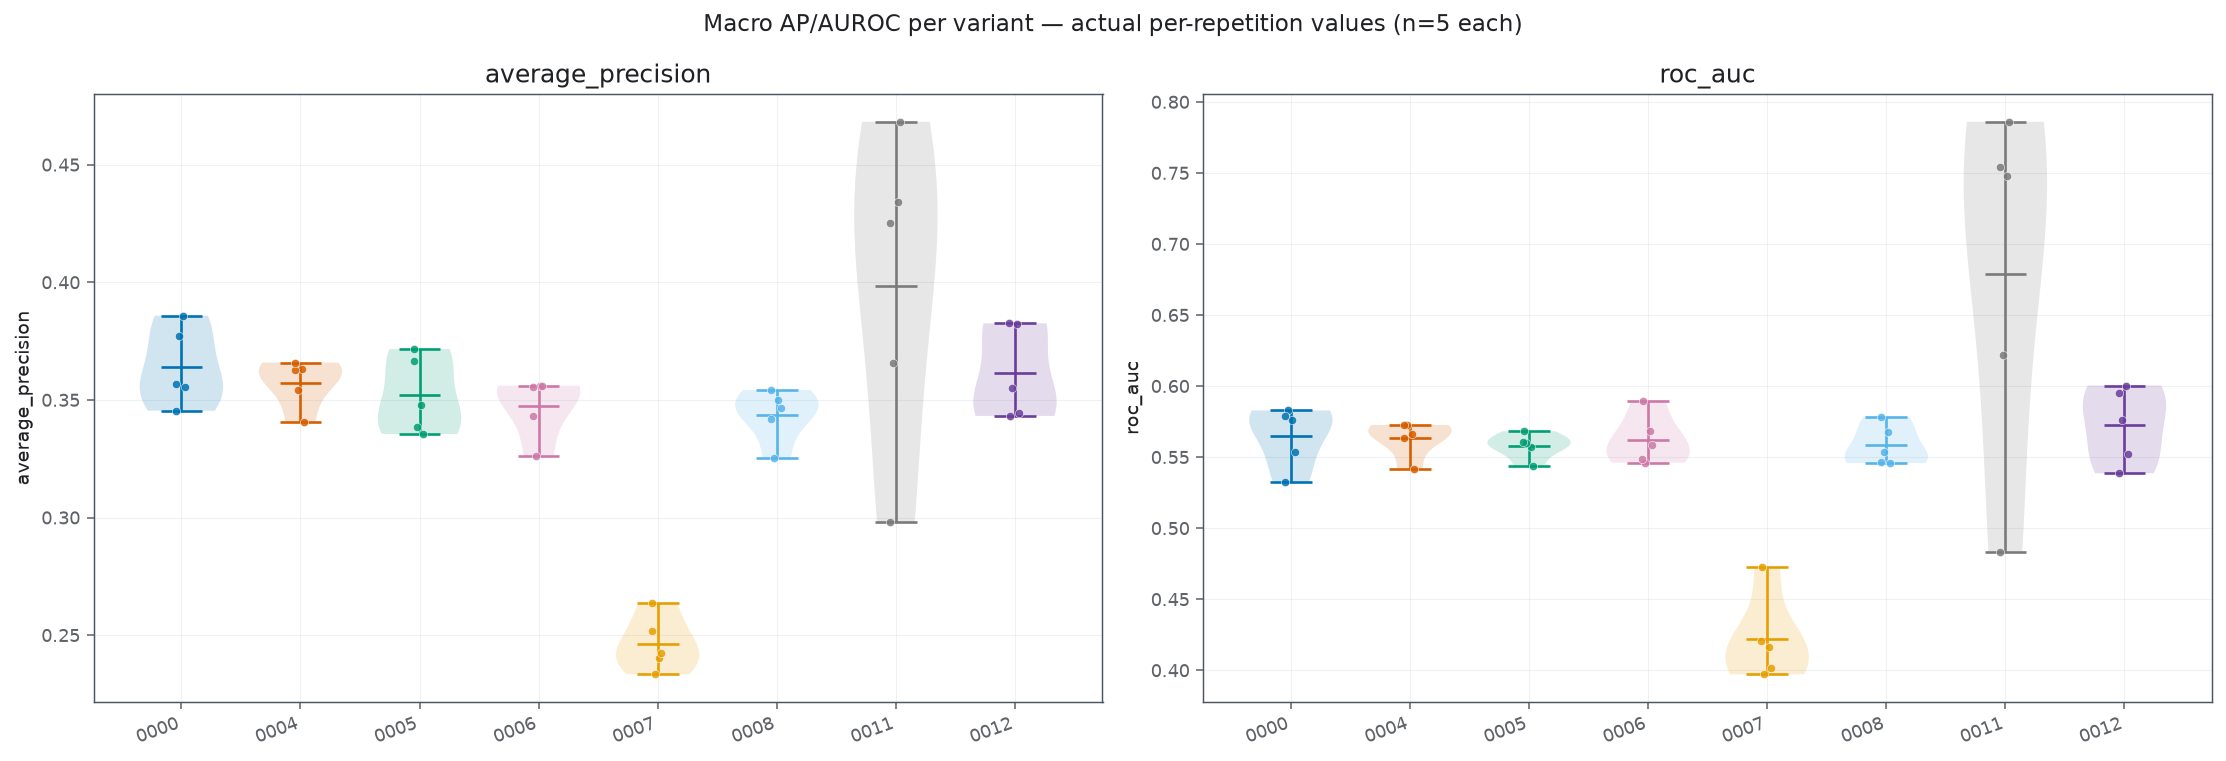

In [6]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

metric_names = ["average_precision", "roc_auc"]
variants = list(VARIANT_SPECS)
figure, axes = plt.subplots(1, len(metric_names), figsize=(16.0, 5.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, metric_names):
    for index, variant in enumerate(variants):
        values = macro_frame.loc[macro_frame["variant"] == variant, metric_name].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
    axis.set_xticks(range(len(variants)))
    axis.set_xticklabels(variants, rotation=20, ha="right")
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Macro AP/AUROC per variant — actual per-repetition values (n=5 each)", fontsize=12)
figure.tight_layout()

## Paired comparisons, checked against `part_9`'s seed null

### Methodology
#### Theoretical
- Each pair in `PAIRS` isolates exactly one design-choice difference between two variants (see the table in the title cell); the resulting AP difference is only trustworthy if it exceeds the seed-to-seed noise either variant would show on its own (rule 4) — read from `part_9`'s already-computed `seed_null_distribution.csv`, not recomputed here, so a change to that file is picked up automatically on re-run.
- The null magnitude used per variant is the mean of all pairwise $|{\rm seed}_a - {\rm seed}_b|$ differences across the 5 repetitions' `average_precision` values, as established in `part_9`. For each pair, the *larger* of the two variants' own nulls is used as the more conservative threshold.

#### Implementation
- `null_mean(variant, metric)`: filters `SEED_NULL_FRAME` (loaded from `seed_null_distribution.csv`) to `variant`/`metryka == metric`, takes one value per repetition (`groupby("repetition")["wartość"].first()`), and computes the mean absolute pairwise difference across all $\binom{5}{2}=10$ repetition pairs (`itertools.combinations`).
- For each `(pair_label, left_variant, right_variant)` in `PAIRS`: `diff = mean(right) - mean(left)` (means over `macro_frame`'s `average_precision`, across the 5 repetitions); `larger_null = max(null_mean(left, "average_precision"), null_mean(right, "average_precision"))`; `signal_over_null = |diff| / larger_null`. The violin+scatter plot below shows both variants' actual 5-repetition `average_precision` distributions side by side for each pair, so the diff/null numbers in the table can be seen directly rather than taken on faith.

### Notes
- `pair_comparison_frame`: `0007 -> 0004` (pos_weight alone) diff = +0.1110, larger_null = 0.0143, signal/null = **7.74**. `0007 -> 0006` (zero-interpretation, with regularizers) diff = +0.1010, larger_null = 0.0146, signal/null = **6.91**. `0011 -> 0012` (zero-interpretation, without regularizers) diff = -0.0368, larger_null = 0.0818, signal/null = 0.45. `0000 -> 0011` (pos_weight alone, without regularizers) diff = +0.0341, larger_null = 0.0818, signal/null = 0.42.
- Both `0007`-involving comparisons clear the null by a wide margin (signal/null ~ 7-8): both `pos_weight` and switching to nnPU each independently and massively fix whatever makes `0007` broken.
- Both `0011`-involving comparisons have signal/null < 1 — the noise floor (driven by `0011`'s own AP std of 0.067, roughly 5x every other variant's) is wider than the observed difference, so neither "pos_weight alone, without regularizers" nor "zero-interpretation, without regularizers" can be read as a real effect from this data.


In [7]:
def null_mean(variant: str, metric: str) -> float:
    rows = SEED_NULL_FRAME[(SEED_NULL_FRAME["variant"] == variant) & (SEED_NULL_FRAME["metryka"] == metric)]
    if rows.empty:
        return float("nan")
    per_rep = rows.groupby("repetition")["wartość"].first().to_numpy()
    from itertools import combinations as _combinations
    diffs = [abs(a - b) for a, b in _combinations(per_rep, 2)]
    return float(np.mean(diffs)) if diffs else float("nan")


pair_comparison_rows = []
for pair_label, left_variant, right_variant in PAIRS:
    left_mean = macro_frame.loc[macro_frame["variant"] == left_variant, "average_precision"].mean()
    right_mean = macro_frame.loc[macro_frame["variant"] == right_variant, "average_precision"].mean()
    diff = right_mean - left_mean
    larger_null = max(null_mean(left_variant, "average_precision"), null_mean(right_variant, "average_precision"))
    pair_comparison_rows.append({
        "pair": pair_label, "left": left_variant, "right": right_variant,
        "mean_left": left_mean, "mean_right": right_mean, "diff_right_minus_left": diff,
        "larger_null": larger_null, "signal_over_null": abs(diff) / larger_null if larger_null > 0 else float("nan"),
    })

pair_comparison_frame = pd.DataFrame(pair_comparison_rows)
pair_comparison_frame

,pair,left,right,mean_left,mean_right,diff_right_minus_left,larger_null,signal_over_null
0,pos_weight alone,0007,0004,0.246376,0.357359,0.110984,0.014346,7.736048
1,"zero-interpretation, with regularizers",0007,0006,0.246376,0.347384,0.101008,0.014616,6.910970
2,"zero-interpretation, without regularizers",0011,0012,0.398353,0.361601,-0.036753,0.081818,0.449199
3,"pos_weight alone, without regularizers",0000,0011,0.364260,0.398353,0.034094,0.081818,0.416700


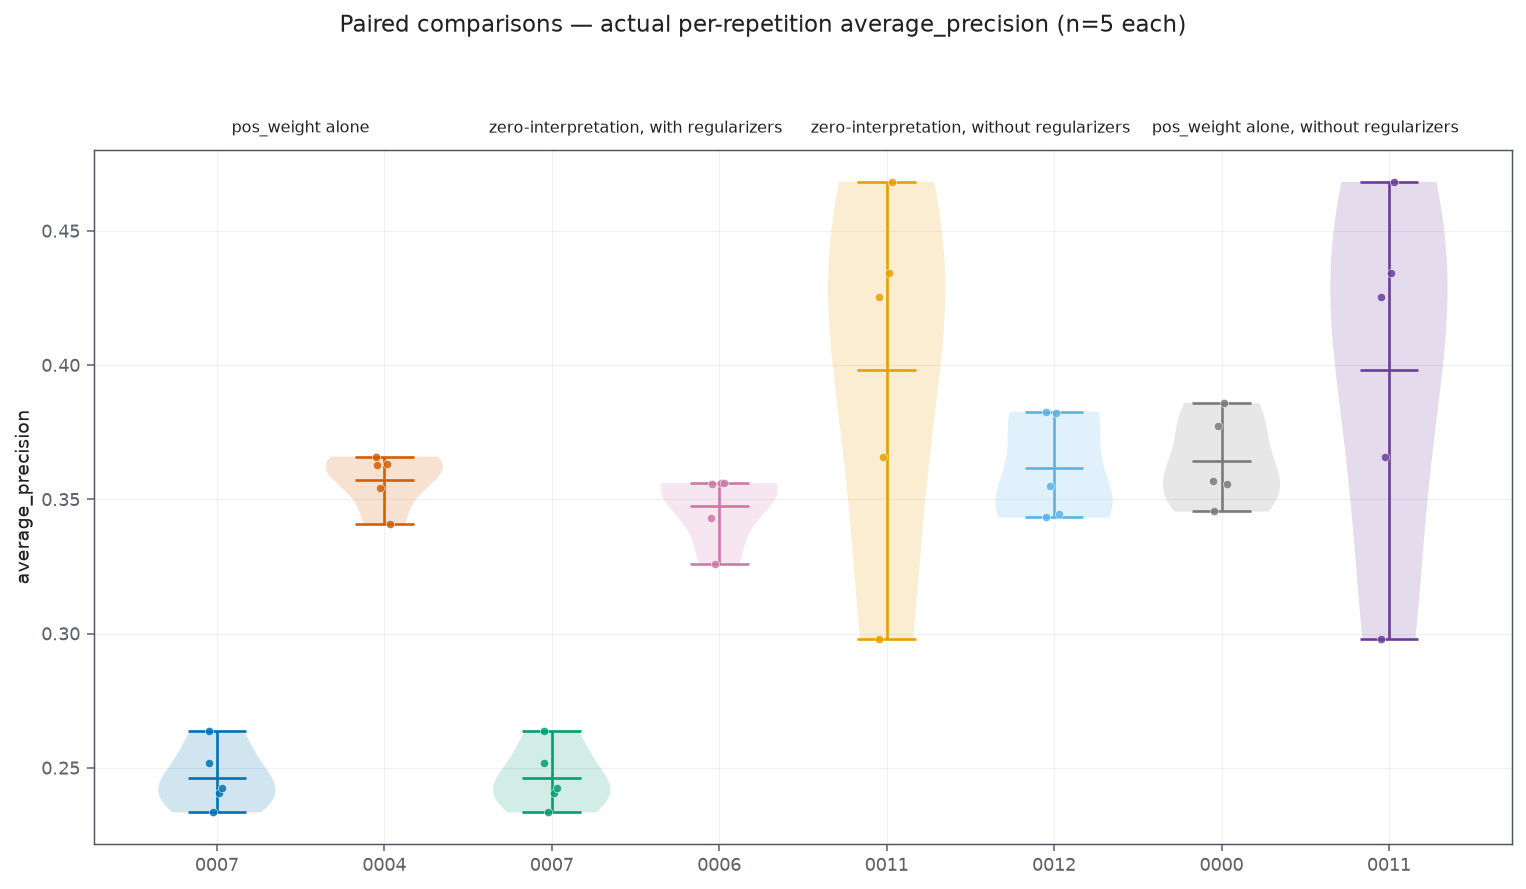

In [8]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

figure, axis = plt.subplots(figsize=(11.0, 6.0), dpi=theme.figure_dpi)
positions, labels = [], []
for pair_index, (pair_label, left_variant, right_variant) in enumerate(PAIRS):
    for side_index, variant in enumerate((left_variant, right_variant)):
        x = pair_index * 2 + side_index
        values = macro_frame.loc[macro_frame["variant"] == variant, "average_precision"].to_numpy()
        plot_violin_with_points(values, position=x, ax=axis, width=0.7, color=theme.color_for_model(variant, x))
        positions.append(x)
        labels.append(variant)
axis.set_xticks(positions)
axis.set_xticklabels(labels)
# Pair labels positioned via the x-data/y-axes-fraction transform, so they sit just
# above the plot area regardless of the data range -- avoids overlapping either the
# violins or a title placed via figure.suptitle (not axis.set(title=...), which sits
# too close to this row of text).
for pair_index, (pair_label, left_variant, right_variant) in enumerate(PAIRS):
    axis.text(pair_index * 2 + 0.5, 1.02, pair_label, ha="center", va="bottom", fontsize=8, transform=axis.get_xaxis_transform())
axis.set(ylabel="average_precision")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Paired comparisons — actual per-repetition average_precision (n=5 each)", fontsize=12, y=1.05)
figure.tight_layout()

## 2x2 factorial: {`bce`,`nnpu`} x {no Jaccard, Jaccard}, with interaction

### Methodology
#### Theoretical
- A 2x2 factorial design (head loss: `bce` vs `nnpu`; Jaccard regularizer: off vs on) separates the two main effects from their interaction, so that "does adding Jaccard help `nnpu` specifically" can be distinguished from "does Jaccard help regardless of head loss" — using only the 4 variants that share the same base regularizer set (`+contractive+InfoNCE`, all *with* regularizers): `0004` (bce, no Jaccard), `0006` (nnpu, no Jaccard), `0005` (bce, Jaccard), `0008` (nnpu, Jaccard).
- Each effect estimate must again be judged against each contributing variant's own repetition-level AP std (from the macro AP/AUROC table above), since no explicit null-ratio is computed in this cell.

#### Implementation
- `cell_means`: mean macro AP (over 5 repetitions, from `macro_frame`) for each of the 4 cells of the design (`FACTORIAL_2X2` maps cell name to variant).
- `head_loss_main_effect = mean(nnpu cells) - mean(bce cells)`; `jaccard_main_effect = mean(jaccard cells) - mean(no-jaccard cells)`; `interaction = (nnpu_jaccard - nnpu_no_jaccard) - (bce_jaccard - bce_no_jaccard)` — the standard 2x2 factorial-design formulas. The violin+scatter plot below shows the actual 5-repetition `average_precision` distribution for each of the 4 design cells the effects above are computed from.

### Notes
- Printed cell means: `bce_no_jaccard` (`0004`) 0.3574, `nnpu_no_jaccard` (`0006`) 0.3474, `bce_jaccard` (`0005`) 0.3521, `nnpu_jaccard` (`0008`) 0.3436.
- `factorial_frame`: `head_loss_main_effect` = -0.0092, `jaccard_main_effect` = -0.0045, `interaction` = +0.0015 — all three magnitudes are an order of magnitude smaller than any of the four variants' own AP std (0.010-0.018). None should be read as a real effect. Once a class-imbalance correction and regularizers are both present, neither which correction (`bce` vs `nnpu`) nor the Jaccard term makes a further detectable difference to macro AP.


In [9]:
cell_means = {
    cell_name: macro_frame.loc[macro_frame["variant"] == variant, "average_precision"].mean()
    for cell_name, variant in FACTORIAL_2X2.items()
}
head_loss_main_effect = (cell_means["nnpu_no_jaccard"] + cell_means["nnpu_jaccard"]) / 2 - (cell_means["bce_no_jaccard"] + cell_means["bce_jaccard"]) / 2
jaccard_main_effect = (cell_means["bce_jaccard"] + cell_means["nnpu_jaccard"]) / 2 - (cell_means["bce_no_jaccard"] + cell_means["nnpu_no_jaccard"]) / 2
interaction = (cell_means["nnpu_jaccard"] - cell_means["nnpu_no_jaccard"]) - (cell_means["bce_jaccard"] - cell_means["bce_no_jaccard"])

factorial_frame = pd.DataFrame([
    {"effect": "head_loss_main_effect (nnpu - bce)", "value": head_loss_main_effect},
    {"effect": "jaccard_main_effect (jaccard - no_jaccard)", "value": jaccard_main_effect},
    {"effect": "interaction", "value": interaction},
])
print("cell means:", cell_means)
factorial_frame

cell means: {'bce_no_jaccard': np.float64(0.3573594742394911), 'nnpu_no_jaccard': np.float64(0.34738371771805854), 'bce_jaccard': np.float64(0.3520582167500353), 'nnpu_jaccard': np.float64(0.3436183451060867)}


,effect,value
0,head_loss_main_effect (nnpu - bce),-0.009208
1,jaccard_main_effect (jaccard - no_jaccard),-0.004533
2,interaction,0.001536


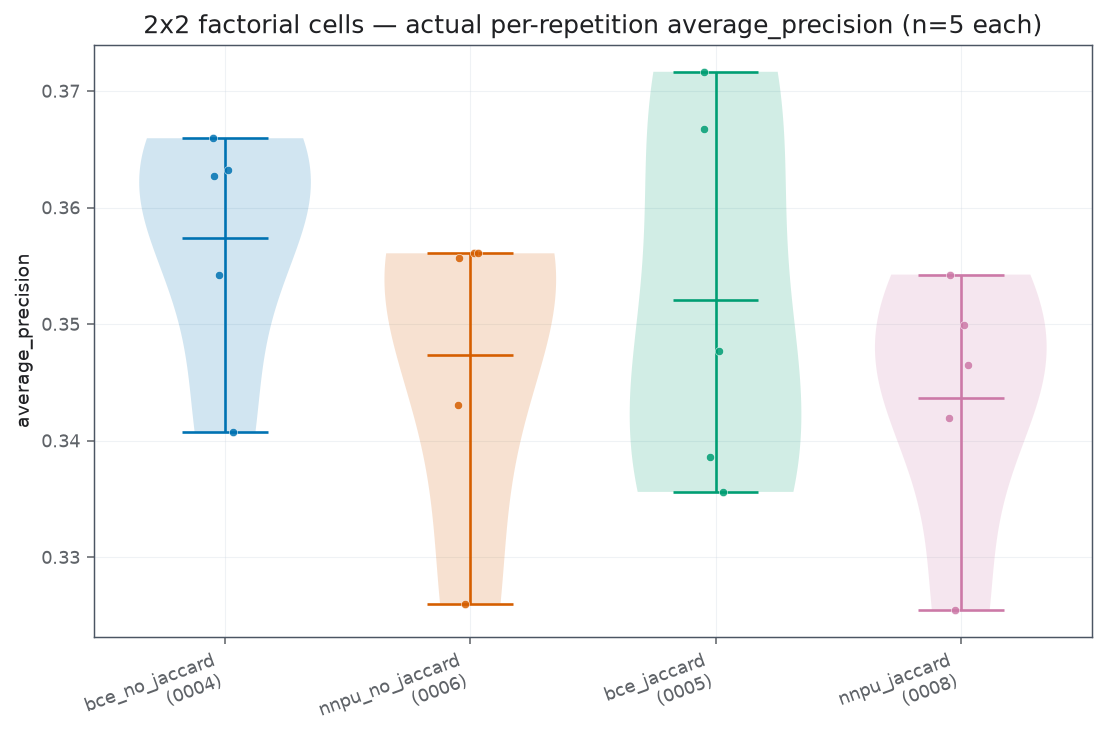

In [10]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

figure, axis = plt.subplots(figsize=(8.0, 5.5), dpi=theme.figure_dpi)
cell_names = list(FACTORIAL_2X2)
for index, cell_name in enumerate(cell_names):
    variant = FACTORIAL_2X2[cell_name]
    values = macro_frame.loc[macro_frame["variant"] == variant, "average_precision"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
axis.set_xticks(range(len(cell_names)))
axis.set_xticklabels([f"{name}\n({FACTORIAL_2X2[name]})" for name in cell_names], rotation=20, ha="right")
axis.set(ylabel="average_precision", title="2x2 factorial cells — actual per-repetition average_precision (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Quality vs. class prevalence — quintile breakdown

### Methodology
#### Theoretical
- Motivating question: does `nnpu`'s prior-based correction flatten the AP-vs-class-prevalence relationship that `max_positive_weight=20`-capped `pos_weight` is known to distort for `bce` (rare classes get capped, heavily-weighted negative pressure regardless of how rare)? Binning classes into prevalence quintiles and comparing mean AP per bin, per variant, tests this directly rather than relying on the single macro-averaged AP number.
- Quintile boundaries are computed from `train` positive counts (not `test`), consistent with expressing `pos_weight`/prior effects as a function of *training* prevalence exposure.

#### Implementation
- `scoreable_classes`: classes with `train_positive_count > 0`. `quintile_edges = np.quantile(train_positive_count[scoreable_classes], np.linspace(0, 1, 6))` splits scoreable classes into `QUINTILE_COUNT=5` equal-population bins; `quintile_assignment = np.digitize(train_positive_count, quintile_edges[1:-1], right=True)` assigns every class (including non-scoreable ones, filtered out below) to quintile 0 (rarest) through 4 (commonest).
- For each (variant, repetition, class): classes with 0 train positives or a NaN `average_precision` are skipped; otherwise the `(quintile, average_precision)` pair is recorded into `quintile_frame`.
- `quintile_summary = quintile_frame.groupby(["variant", "quintile"])["average_precision"].mean().unstack("quintile")`, plus `spread_q4_minus_q0 = quintile_summary[4] - quintile_summary[0]` as a compact flattening measure. The following cell plots one line per variant across the 5 quintiles (`ax.plot`, x = quintile, y = mean AP).

### Notes
- `quintile_summary`, Q0 (rarest) AP: `0000` 0.299, `0004` 0.308, `0005` 0.296, **`0006` 0.127**, `0007` 0.290, **`0008` 0.140**, `0011` 0.320, `0012` 0.284. Q4 (commonest) AP ranges 0.424-0.739 across variants with no comparably sharp outlier.
- `0006`/`0008` (the two nnPU variants *with* regularizers, `+contractive+InfoNCE`) score far worse than every other variant specifically on Q0 (0.127/0.140 vs. 0.28-0.32 elsewhere) — nnPU does not flatten the prevalence dependency here; if anything it makes the rarest-class quintile notably worse, the opposite of the motivating hypothesis.
- `0012` (nnPU, *without* regularizers) shows no such drop (Q0 = 0.284, in line with the `bce` variants) — the Q0 collapse is specific to the nnPU + `+contractive+InfoNCE` combination, not a property of nnPU alone.
- `spread_q4_minus_q0` is largest for `0006` (0.446) and `0012` (0.445), smallest for `0007` (0.134) — but `0007`'s low spread reflects its already-poor Q4 ceiling (0.424) rather than a flattened/improved Q0, consistent with `0007` being broken overall (see the AP/AUROC and calibration cells).


In [11]:
scoreable_classes = np.where(train_positive_count > 0)[0]
quintile_edges = np.quantile(train_positive_count[scoreable_classes], np.linspace(0, 1, QUINTILE_COUNT + 1))
quintile_assignment = np.digitize(train_positive_count, quintile_edges[1:-1], right=True)

quintile_rows = []
for variant in VARIANT_SPECS:
    for repetition in REPETITIONS:
        frame = per_class_frames[(variant, repetition)]
        for class_index in frame.index:
            if train_positive_count[int(class_index)] <= 0 or np.isnan(frame.loc[class_index, "average_precision"]):
                continue
            quintile_rows.append({
                "variant": variant, "repetition": repetition, "class_index": class_index,
                "quintile": int(quintile_assignment[int(class_index)]),
                "average_precision": frame.loc[class_index, "average_precision"],
            })

quintile_frame = pd.DataFrame(quintile_rows)
quintile_summary = quintile_frame.groupby(["variant", "quintile"])["average_precision"].mean().unstack("quintile")
quintile_summary["spread_q4_minus_q0"] = quintile_summary[QUINTILE_COUNT - 1] - quintile_summary[0]
quintile_summary

quintile,0,1,2,3,4,spread_q4_minus_q0
variant,,,,,,
0000,0.299049,0.384817,0.363342,0.407177,0.739131,0.440082
0004,0.308045,0.432859,0.482863,0.337082,0.538310,0.230265
0005,0.296040,0.434644,0.484761,0.332828,0.561430,0.265389
0006,0.126605,0.402100,0.472930,0.343725,0.572616,0.446011
0007,0.290024,0.392200,0.471331,0.338687,0.424453,0.134429
0008,0.139713,0.400572,0.476036,0.344725,0.565273,0.425560
0011,0.319765,0.393327,0.410572,0.408261,0.722619,0.402854
0012,0.283659,0.395545,0.364781,0.442873,0.728374,0.444715


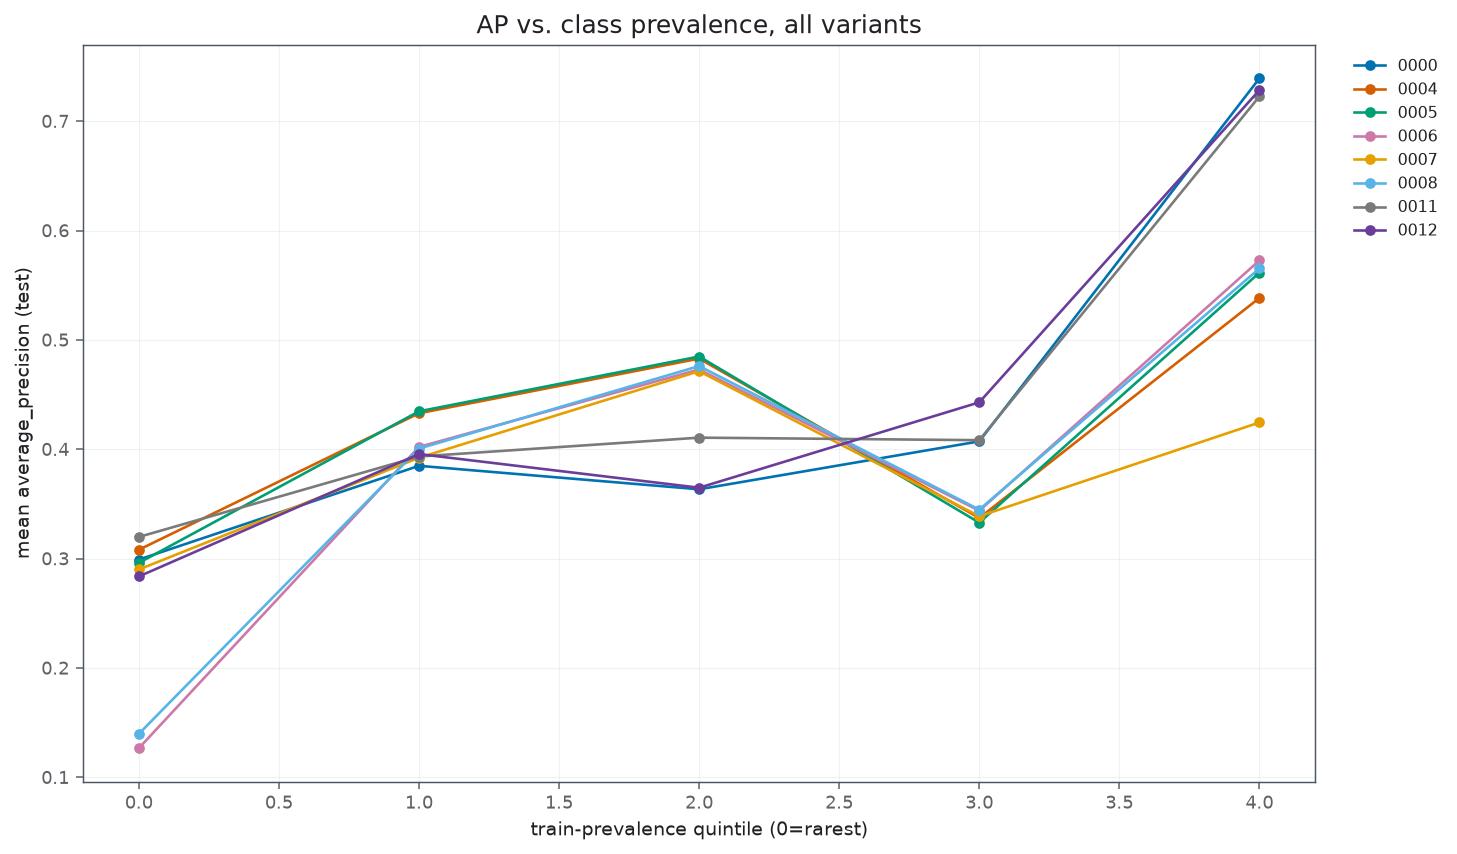

In [12]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, variant in enumerate(VARIANT_SPECS):
    values = [quintile_summary.loc[variant, q] for q in range(QUINTILE_COUNT)]
    ax.plot(range(QUINTILE_COUNT), values, marker="o", color=theme.color_for_model(variant, index), label=variant)
ax.set(xlabel="train-prevalence quintile (0=rarest)", ylabel="mean average_precision (test)", title="AP vs. class prevalence, all variants")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=theme.legend_frame, fontsize=8)
figure.tight_layout()

## Predicted-positive fraction at threshold 0.5 vs. true prevalence

### Methodology
#### Theoretical
- Comparing the fraction of (class, pixel) pairs predicted positive at a fixed threshold (0.5) against the true positive fraction tests *calibration* (are predicted probabilities well-scaled?), not discrimination/ranking quality, which is already covered by AP/AUROC — per this project's rule 1, threshold-0.5 metrics are read only as a calibration diagnostic, never as a ranking-quality comparison.
- `pos_weight` and nnPU's prior correction both explicitly reweight the loss to counteract class imbalance; a large "predicted positive fraction" at 0.5 is an expected side effect of that correction (predictions pushed up, away from majority-class collapse), not evidence of poor discrimination.

#### Implementation
- `true_positive_fraction = (test_targets * test_mask).sum() / test_mask.sum()`, computed once per campaign (shared test split), pooled across all classes and pixels.
- `predicted_positive_fraction_at_0.5 = ((probabilities >= THRESHOLD) & test_mask).sum() / test_mask.sum()`, per (variant, repetition), using the same pooled-across-all-classes convention.
- Aggregated via `calibration_summary_frame.groupby("variant")[["true_positive_fraction", "predicted_positive_fraction_at_0.5"]].mean()` over the 5 repetitions. The violin+scatter plot below shows the actual 5 per-repetition `predicted_positive_fraction_at_0.5` values per variant (`true_positive_fraction` is excluded there — it is a ground-truth-only constant, identical across every repetition of a variant, so there is no repetition-to-repetition spread to show).

### Notes
- `true_positive_fraction` = 0.0574 (5.74%) — identical across all variants (same underlying `test` labels).
- `predicted_positive_fraction_at_0.5`: `0000` 31.5%, `0004` 30.1%, `0005` 30.0%, `0006` 32.0%, `0008` 32.0%, `0012` 34.4% — all variants with *some* imbalance correction massively over-predict positives at threshold 0.5 relative to the true 5.7%, as expected from the correction mechanism itself.
- `0007` 0.17% and `0011` 0.42% — both uncorrected variants drastically *under*-predict instead, consistent with unweighted BCE's natural bias toward the majority (negative) class.
- `0012` (nnPU, no regularizers) reaches 34.4%, higher than any `pos_weight`-corrected variant and far above `0011` (plain unweighted bce, 0.42%) — nnPU's prior mechanism visibly corrects calibration even without regularizers.


In [13]:
calibration_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    test_targets_np, test_mask_np = test_targets_masks_by_campaign[campaign_id]
    true_positive_fraction = float((test_targets_np * test_mask_np).sum() / test_mask_np.sum())
    for repetition in REPETITIONS:
        probabilities = probabilities_by_variant_repetition[(variant, repetition)]
        predicted_positive_fraction = float(((probabilities >= THRESHOLD) & test_mask_np).sum() / test_mask_np.sum())
        calibration_rows.append({
            "variant": variant, "repetition": repetition,
            "true_positive_fraction": true_positive_fraction,
            "predicted_positive_fraction_at_0.5": predicted_positive_fraction,
        })

calibration_summary_frame = pd.DataFrame(calibration_rows)
calibration_summary_frame.groupby("variant")[["true_positive_fraction", "predicted_positive_fraction_at_0.5"]].mean()

,true_positive_fraction,predicted_positive_fraction_at_0.5
variant,,
0000,0.057393,0.315027
0004,0.057393,0.301167
0005,0.057393,0.300429
0006,0.057393,0.320264
0007,0.057393,0.001692
0008,0.057393,0.320256
0011,0.057393,0.004198
0012,0.057393,0.344119


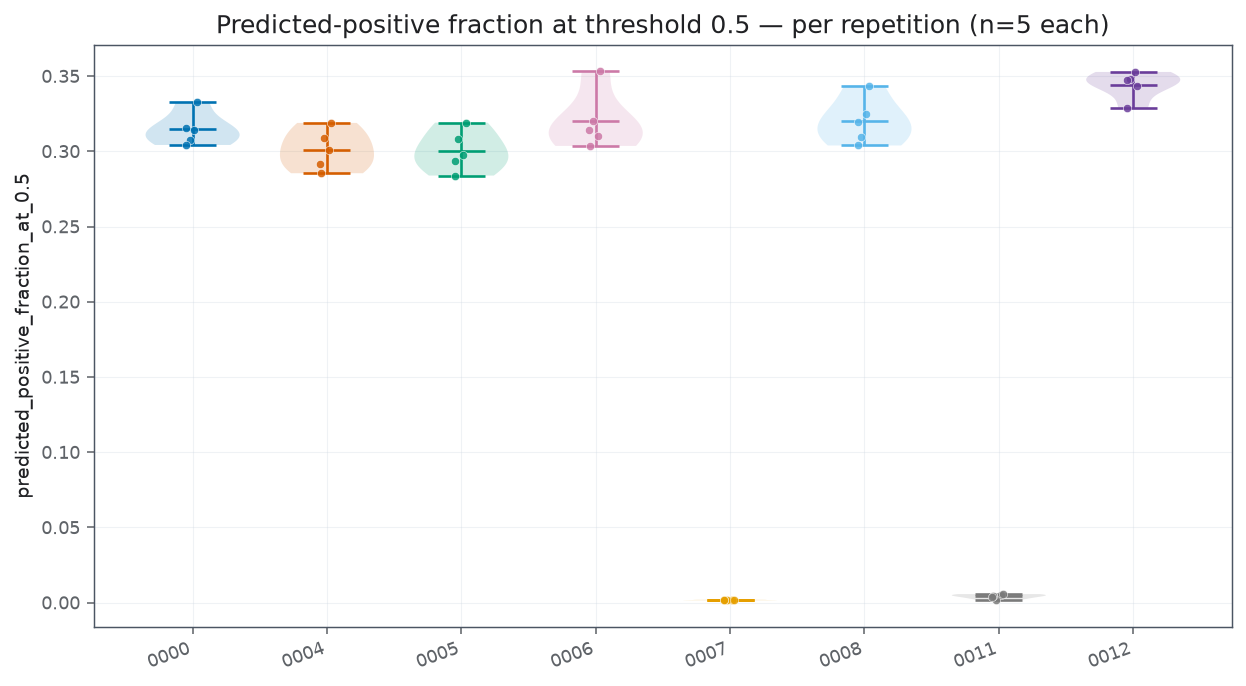

In [14]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

# true_positive_fraction depends only on ground truth (test_targets_np/test_mask_np),
# identical across all 5 repetitions of a variant -- no repetition-to-repetition
# spread to show, so only predicted_positive_fraction_at_0.5 (which does depend on
# the model) gets a violin here.
figure, axis = plt.subplots(figsize=(9.0, 5.0), dpi=theme.figure_dpi)
variants = list(VARIANT_SPECS)
for index, variant in enumerate(variants):
    values = calibration_summary_frame.loc[calibration_summary_frame["variant"] == variant, "predicted_positive_fraction_at_0.5"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
axis.set_xticks(range(len(variants)))
axis.set_xticklabels(variants, rotation=20, ha="right")
axis.set(ylabel="predicted_positive_fraction_at_0.5", title="Predicted-positive fraction at threshold 0.5 — per repetition (n=5 each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Reliability curves (pooled across all active classes, repetition 0)

### Methodology
#### Theoretical
- A reliability (calibration) curve plots observed positive fraction against mean predicted probability within probability bins, directly visualizing calibration quality across the whole probability range — a finer-grained complement to the single-threshold (0.5) fraction comparison in the previous cell.
- Only repetition 0 is used per variant (not averaged across repetitions), since this is a diagnostic visualization, not a metric being compared quantitatively across seeds.

#### Implementation
- For each variant, predictions/targets are pooled across all classes and pixels via the test mask (`test_targets_np[test_mask_np]`, `probabilities[test_mask_np]`, using `probabilities_by_variant_repetition[(variant, 0)]`), then `sklearn.calibration.calibration_curve(flat_true, flat_probabilities, n_bins=15, strategy="quantile")` bins predictions into 15 equal-*population* bins (quantile strategy, not equal-width) and returns `(fraction_positive, mean_predicted)` per bin.
- One line per variant (`ax.plot(mean_predicted, fraction_positive, ...)`), plus a diagonal "perfect calibration" reference line.

### Notes
- The cell produces a single `image/png` figure with no additional printed values. The plotted curves visualize, at finer resolution, the same discrepancy already quantified numerically in the previous cell (e.g. `0007`/`0011` under-predicting relative to the diagonal, the other variants over-predicting near the 0.5 region).
- No numeric output beyond the figure is captured in the notebook for this cell.


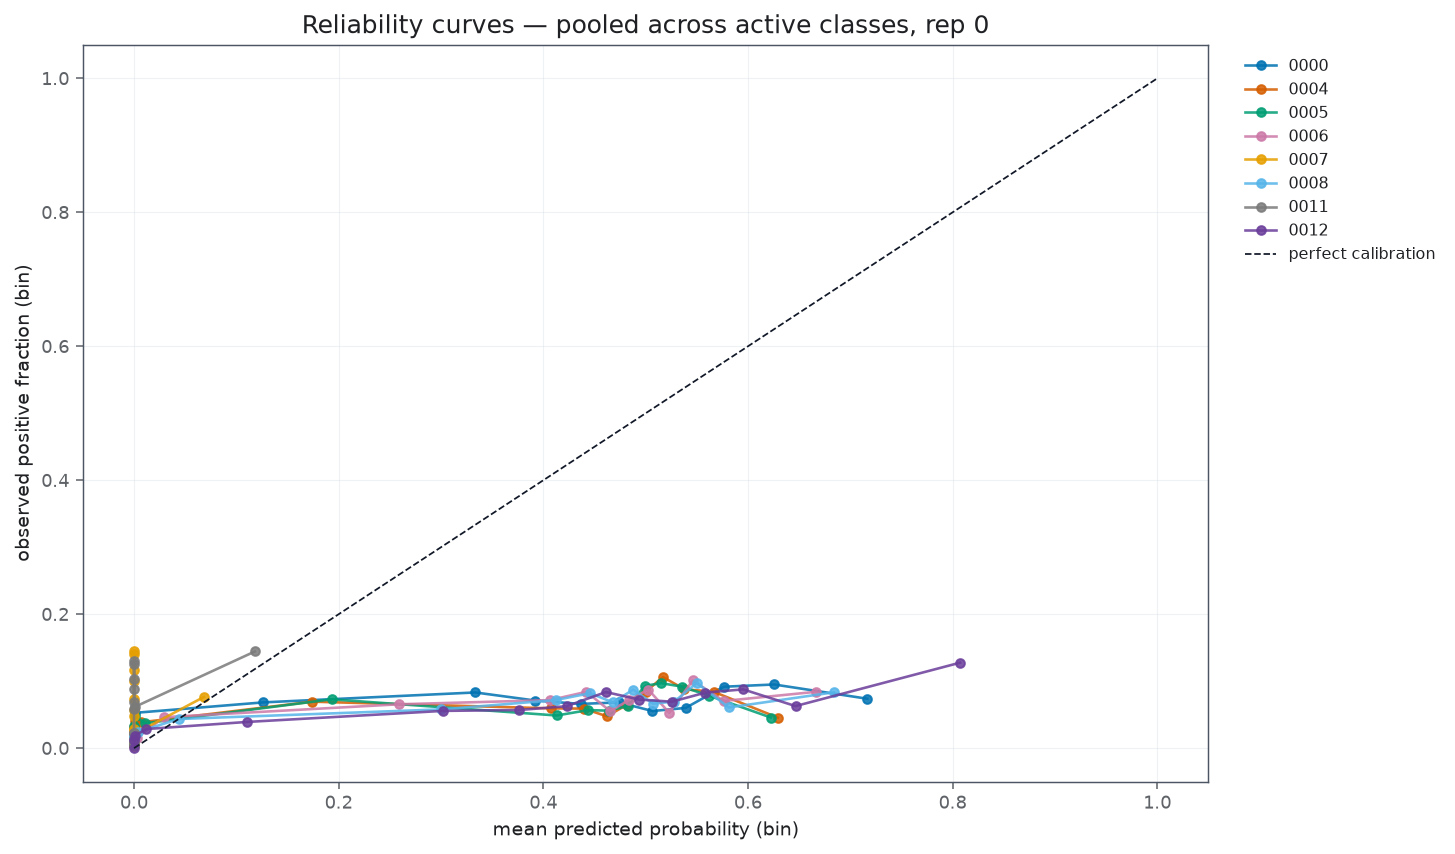

In [15]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, (variant, (campaign_id, grid_id)) in enumerate(VARIANT_SPECS.items()):
    test_targets_np, test_mask_np = test_targets_masks_by_campaign[campaign_id]
    probabilities = probabilities_by_variant_repetition[(variant, 0)]
    flat_true = test_targets_np[test_mask_np].astype(bool)
    flat_probabilities = probabilities[test_mask_np]
    fraction_positive, mean_predicted = calibration_curve(flat_true, flat_probabilities, n_bins=15, strategy="quantile")
    ax.plot(mean_predicted, fraction_positive, marker="o", color=theme.color_for_model(variant, index), label=variant, alpha=theme.primary_alpha)
ax.plot([0, 1], [0, 1], color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="perfect calibration")
ax.set(xlabel="mean predicted probability (bin)", ylabel="observed positive fraction (bin)", title="Reliability curves — pooled across active classes, rep 0")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=theme.legend_frame, fontsize=8)
figure.tight_layout()

In [16]:
output_rows = []
for _, row in macro_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("average_precision", "roc_auc"):
        output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": metric_name, "wartość": row[metric_name]})
for _, row in pair_comparison_frame.iterrows():
    for metric_name in ("diff_right_minus_left", "larger_null", "signal_over_null"):
        output_rows.append({"campaign": "nnpu_followup", "variant": row["pair"], "repetition": f"{row['left']}_vs_{row['right']}", "metryka": metric_name, "wartość": row[metric_name]})
for _, row in factorial_frame.iterrows():
    output_rows.append({"campaign": "nnpu_followup", "variant": "factorial_2x2", "repetition": row["effect"], "metryka": "ap_effect", "wartość": row["value"]})
for _, row in calibration_summary_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": "predicted_positive_fraction_at_0.5", "wartość": row["predicted_positive_fraction_at_0.5"]})
    output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": "true_positive_fraction", "wartość": row["true_positive_fraction"]})

factor_decomposition_frame = pd.DataFrame(output_rows)
factor_decomposition_frame.to_csv(RESULTS_DIRECTORY / "factor_decomposition.csv", index=False)
quintile_frame.to_csv(RESULTS_DIRECTORY / "factor_decomposition_prevalence_quintiles.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'factor_decomposition.csv'} ({len(factor_decomposition_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/factor_decomposition.csv (175 rows)


## Notes for the next pass

**Headline: `0007` (plain `bce`, no `pos_weight`, but *with* `+contractive+InfoNCE`)
is uniquely broken, and either remedy — adding `pos_weight` or switching to nnPU —
fixes it by a massive, clearly-real margin. Comparisons routed through `0011` do not
survive the null, because `0011` itself is unstable (confirmed again here).**

### AP / AUROC table

| variant | AP mean (std) | AUROC mean (std) |
|---|---|---|
| `0000` | 0.364 (0.017) | 0.565 (0.021) |
| `0004` | 0.357 (0.010) | 0.563 (0.013) |
| `0005` | 0.352 (0.016) | 0.558 (0.009) |
| `0006` | 0.347 (0.013) | 0.562 (0.018) |
| **`0007`** | **0.246 (0.012)** | **0.422 (0.030)** |
| `0008` | 0.344 (0.011) | 0.558 (0.014) |
| `0011` | 0.398 (0.067) | 0.679 (0.126) |
| `0012` | 0.362 (0.020) | 0.572 (0.027) |

`0007`'s mean AUROC (0.422) is **below 0.5** — worse than a random ranking, on
average across its 113 scoreable classes. This is not one outlier class dragging
the mean; it is a genuinely broken classifier by this metric.

### Paired comparisons vs. `part_9`'s seed null

| pair | diff (right - left) | larger null | signal/null |
|---|---|---|---|
| `0007` -> `0004` (pos_weight alone) | +0.111 | 0.014 | **7.74** |
| `0007` -> `0006` (zero-interp., with reg.) | +0.101 | 0.015 | **6.91** |
| `0011` -> `0012` (zero-interp., without reg.) | -0.037 | 0.082 | 0.45 |
| `0000` -> `0011` (pos_weight alone, without reg.) | +0.034 | 0.082 | 0.42 |

- **Both fixes for `0007` are massive and essentially tied in magnitude** (+0.111 vs.
  +0.101 AP, signal/null 7.7 and 6.9 — among the cleanest effects found anywhere in
  this whole follow-up). Adding `pos_weight` and switching to nnPU's prior
  correction are, in the *with-regularizers* regime, essentially interchangeable
  remedies for the same underlying problem: `+contractive+InfoNCE` combined with
  **no** class-imbalance correction of any kind produces a badly broken classifier.
- **Neither `0011`-involving pair survives** — both ratios are well below 1,
  confirming `part_9`'s flag: `0011`'s own seed-to-seed null (0.082, driven by its
  0.067 AP std) is wide enough to swallow both differences. No conclusion about
  "pos_weight alone, without regularizers" or "zero-interpretation, without
  regularizers" can be drawn from these two pairs at 5 repetitions.

### 2x2 factorial (`0004`/`0005`/`0006`/`0008` — all *with* regularizers)

`head_loss_main_effect` (nnpu - bce) = -0.0092, `jaccard_main_effect` = -0.0045,
`interaction` = +0.0015 — all three are smaller than the individual variants' own
AP nulls (0.010-0.018 std), so none of them should be read as real. Confirms and
extends the earlier finding (`part_5`/`part_6`/`part_10`) that once `pos_weight` or
nnPU's correction is present *and* regularizers are present, further small changes
(which correction, Jaccard on/off) stop mattering — the large effect is entirely in
*having* a correction at all, not in which one.

### Quality vs. prevalence quintiles — contradicts the "nnPU flattens it" hypothesis

| variant | Q0 (rarest) | Q4 (commonest) | spread |
|---|---|---|---|
| `0000` (bce+pos_weight, no reg.) | 0.299 | 0.739 | 0.440 |
| `0004` (bce+pos_weight, +reg.) | 0.308 | 0.538 | 0.230 |
| **`0006`** (nnpu, +reg.) | **0.127** | 0.573 | 0.446 |
| **`0008`** (nnpu+jaccard, +reg.) | **0.140** | 0.565 | 0.426 |
| `0011` (bce no pos_weight, no reg.) | 0.320 | 0.723 | 0.403 |
| `0012` (nnpu, no reg.) | 0.284 | 0.728 | 0.445 |

**`0006`/`0008` (nnPU *with* regularizers) score dramatically worse than every other
variant specifically on the rarest-class quintile** (0.127/0.140 vs. 0.28-0.32
everywhere else) — nnPU does not flatten the prevalence dependency here; if
anything it makes the rarest classes notably worse, and only when combined with
`+contractive+InfoNCE`. `0012` (nnPU *without* regularizers) shows no such problem
(Q0 = 0.284, in line with the `bce` variants) — this is a regularizer-nnPU
interaction specifically, not a property of nnPU alone. Worth flagging clearly:
this is the opposite of what the task spec's hypothesis anticipated.

### Calibration at threshold 0.5 (true positive rate: 5.7%)

| variant | predicted positive fraction |
|---|---|
| `0000`/`0004`/`0005`/`0006`/`0008` | 30.0-32.0% |
| **`0007`** | **0.17%** |
| **`0011`** | **0.42%** |
| `0012` | 34.4% |

Every variant with *some* correction (`pos_weight` or nnPU's prior) massively
over-predicts positives at 0.5 (~30-34%, matching the task spec's own quoted ~31%
reference point for `bce+pos_weight`) — expected, threshold 0.5 measures calibration,
not discrimination (rule 1). `0007` and `0011` (both entirely uncorrected)
drastically *under*-predict instead (<0.5%) — consistent with unweighted BCE's
natural bias toward the majority (negative) class. Notably, `0012` (nnPU, no
regularizers) reaches 34.4% — nnPU's prior mechanism visibly corrects calibration
even without regularizers, unlike plain unweighted `bce` (`0011`, 0.42%) — a clean
confirmation that the two mechanisms (pos_weight, nnPU prior) both do what they are
supposed to for calibration, independent of the regularizer question.